In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("cherngs/heart-disease-cleveland-uci")
print("Path to dataset files:", path)
# List files in the directory to find the CSV file
file_list = os.listdir(path)
print("Files in directory:", file_list)
# Assuming the CSV file is named 'heart.csv' or similar, modify as needed
csv_file_path = os.path.join(path, 'heart_cleveland_upload.csv') # Replace 'heart.csv' with the actual filename if different

Using Colab cache for faster access to the 'heart-disease-cleveland-uci' dataset.
Path to dataset files: /kaggle/input/heart-disease-cleveland-uci
Files in directory: ['heart_cleveland_upload.csv']


In [ ]:
df = pd.read_csv(csv_file_path)
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df = df.apply(pd.to_numeric)
print(df.shape)
df.head()

(297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [ ]:
X = df.drop(['condition'],axis=1)
y = df['condition']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(probability=True, random_state=42))
])

In [ ]:
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.1, 0.01],
    'model__kernel': ['rbf']
}

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

Best Parameters: {'model__C': 1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV F1 Score: 0.7991133844842284


In [ ]:
y_proba = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

y_pred = (y_proba >= optimal_threshold).astype(int)

Optimal Threshold: 0.3636260590085878


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Accuracy: 0.9166666666666666
Precision: 0.96
Recall: 0.8571428571428571
F1 Score: 0.9056603773584906
AUROC: 0.9274553571428571
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        32
           1       0.96      0.86      0.91        28

    accuracy                           0.92        60
   macro avg       0.92      0.91      0.92        60
weighted avg       0.92      0.92      0.92        60



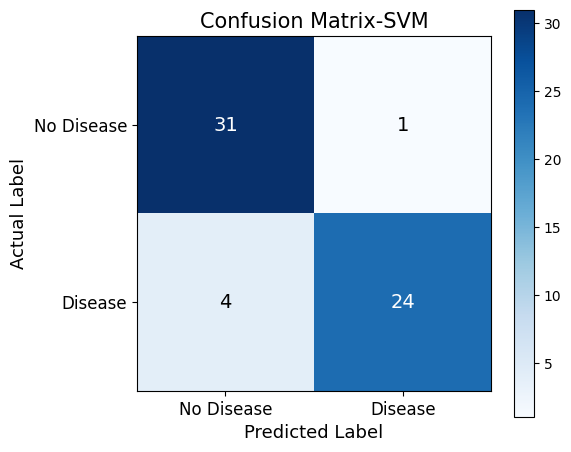

In [ ]:
# CONFUSION MATRIX
# y_test: ground truth, y_pred: predicted class labels
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix-SVM', fontsize=15)
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No Disease', 'Disease'], fontsize=12)
plt.yticks(tick_marks, ['No Disease', 'Disease'], fontsize=12)
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('Actual Label', fontsize=13)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=14)
plt.tight_layout()
plt.grid(False)
plt.show()

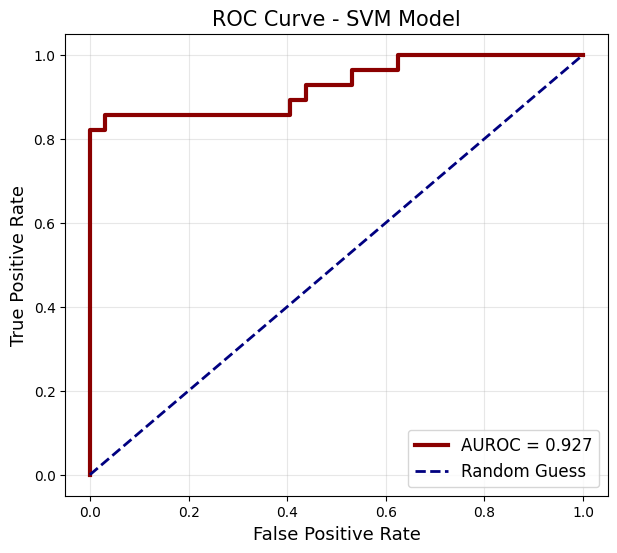

In [ ]:
# ROC CURVE
# y_test: ground truth labels
# y_proba: predicted probabilities for positive class (model.predict_proba(X_test)[:,1])

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkred', lw=3, label=f'AUROC = {auc_value:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - SVM Model', fontsize=15)
plt.legend(loc='lower right', fontsize=12)


plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Predict for a random patient
import random
rand_index = random.randint(0, X_test.shape[0]-1)
patient_features = X_test.iloc[rand_index].values.reshape(1, -1)
true_label = y_test.iloc[rand_index]
pred_prob = best_model.predict_proba(patient_features)[0][1]
pred_class = int(pred_prob >= optimal_threshold)
print("\nRandom Patient Details:")
print(X_test.iloc[rand_index])
print("\nTrue Condition:", "Heart Disease" if true_label == 1 else "No Disease")
print(f"Predicted Probability of Heart Disease: {pred_prob*100:.2f}%")
print("Predicted Class:", "Heart Disease" if pred_class == 1 else "No Disease")


Random Patient Details:
age          62.0
sex           1.0
cp            1.0
trestbps    120.0
chol        281.0
fbs           0.0
restecg       2.0
thalach     103.0
exang         0.0
oldpeak       1.4
slope         1.0
ca            1.0
thal          2.0
Name: 28, dtype: float64

True Condition: Heart Disease
Predicted Probability of Heart Disease: 72.37%
Predicted Class: Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

# best_model is the full Pipeline (StandardScaler + SVC) — dump the whole thing
os.makedirs('pkl_files', exist_ok=True)
joblib.dump(best_model, 'pkl_files/svm.pkl')

# Verify
loaded = joblib.load('pkl_files/svm.pkl')
test_prob = loaded.predict_proba(X_test[:1])[0][1]
print(f"SVM pkl verified. Sample prob: {test_prob:.4f}")
print(f"Optimal threshold locked: {optimal_threshold:.4f}")
print("SVM pipeline (with scaler) saved successfully.")

SVM pkl verified. Sample prob: 0.1202
Optimal threshold locked: 0.3636
SVM pipeline (with scaler) saved successfully.
